# Examen Práctico — Primer Parcial
## Tópicos de Big Data

**Instrucciones generales**

- Este notebook es tu entregable. Complétalo en orden, sin borrar los enunciados.
- Al final debes subir este archivo (`.ipynb`) al repositorio de GitHub del curso, en la carpeta correspondiente a tu nombre/usuario.
- Se evaluará tanto el código (que corra sin errores, de arriba hacia abajo) como tus interpretaciones escritas en las celdas de texto marcadas como *"Interpretación"*.
- Cada quien trabaja con **un dataset distinto**, asignado por la profesora. No copies celdas de un compañero con un dataset diferente: aunque las preguntas se parecen, los datos y las columnas no son las mismas.


## 0. Datos del alumno

Completa la siguiente celda con tus datos y el nombre del dataset que te fue asignado.

In [92]:
# --- COMPLETA CON TUS DATOS ---
NOMBRE = "Pablo Eduardo Magaña Gutierrez"            # Tu nombre completo
MATRICULA = "82260"         # Tu matrícula o número de cuenta
DATASET_ASIGNADO = "migracion"  # Debe ser uno de: "alcohol", "migracion", "desnutricion", "pib", "homicidios"

print(f"Alumno: {NOMBRE}")
print(f"Matrícula: {MATRICULA}")
print(f"Dataset asignado: {DATASET_ASIGNADO}")


Alumno: Pablo Eduardo Magaña Gutierrez
Matrícula: 82260
Dataset asignado: migracion


## 1. Configuración del entorno virtual (Visual Studio Code)

Antes de instalar librerías directamente en tu sistema, es una buena práctica crear un
**entorno virtual** exclusivo para este examen. Esto evita conflictos de versiones con
otros proyectos y hace que tu entorno de trabajo sea reproducible.

**Requisitos previos en VS Code:** ten instaladas las extensiones oficiales **"Python"**
y **"Jupyter"** (ambas de Microsoft), disponibles en la pestaña de Extensiones (ícono de
cuadritos en la barra lateral izquierda, o `Ctrl+Shift+X` / `Cmd+Shift+X`).

Abre una terminal **dentro de VS Code** (menú **Terminal → New Terminal**, o
`` Ctrl+ñ ``/`` Ctrl+` ``) y verifica que estés ubicado en la carpeta de tu repositorio
del curso (donde vas a guardar este notebook).

### Windows (PowerShell, terminal integrada de VS Code)

```powershell
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python -m venv .venv

# 2. Activar el entorno virtual
.venv\Scripts\Activate.ps1

# Si PowerShell bloquea la ejecución de scripts, ejecuta una sola vez:
#   Set-ExecutionPolicy -Scope CurrentUser RemoteSigned
# y vuelve a intentar activar el entorno.

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

### macOS / Linux (terminal integrada de VS Code, bash o zsh)

```bash
# 1. Crear el entorno virtual (se creará una carpeta llamada ".venv")
python3 -m venv .venv

# 2. Activar el entorno virtual
source .venv/bin/activate

# 3. Instalar las librerías necesarias
pip install pandas numpy ipykernel matplotlib requests
```

> **Nota:** usamos el nombre `.venv` (con punto) porque VS Code lo detecta automáticamente
> dentro de la carpeta del proyecto. Si usas Anaconda/Miniconda en lugar de `venv`, el
> equivalente es:
> ```bash
> conda create -n examen-bigdata python=3.11 pandas numpy ipykernel matplotlib requests -y
> conda activate examen-bigdata
> ```

### Seleccionar el entorno virtual como kernel en VS Code

A diferencia de Jupyter Notebook/Lab, en VS Code **no necesitas registrar el entorno
manualmente con `ipykernel install`**: basta con tener el paquete `ipykernel` instalado
en el entorno (ya quedó instalado en el paso anterior) y seleccionar ese entorno
directamente como kernel del notebook.

1. Abre este archivo `.ipynb` en VS Code.
2. En la esquina superior derecha del notebook, haz clic en el selector de kernel
   (dice algo como **"Select Kernel"** la primera vez).
3. Elige **"Python Environments..."** y de la lista selecciona el entorno `.venv`
   que acabas de crear (debe aparecer como algo como `.venv (Python 3.x.x)` con la
   ruta de tu proyecto).
4. Si no aparece en la lista, haz clic en **"Select Another Kernel" → "Python
   Environments..."** y usa **"Enter interpreter path..."** para localizar manualmente
   el ejecutable dentro de `.venv/bin/python` (macOS/Linux) o `.venv\Scripts\python.exe`
   (Windows).
5. Verifica que quedó bien seleccionado ejecutando la celda de abajo: debe mostrar una
   ruta que contenga la carpeta `.venv` (o el nombre de tu entorno de conda), y no la
   instalación global de Python.

In [93]:
import sys
print(sys.executable)
# Debe mostrar una ruta dentro de tu carpeta "venv" (o de tu entorno "examen-bigdata" si usas conda).
# Si muestra la ruta de tu instalacion global de Python, regresa al paso anterior
# y selecciona el kernel correcto antes de continuar.


c:\Users\PMaganaC\OneDrive\Documentos\Universidad\semestre 5\bigdata\Examen 1\.venv\Scripts\python.exe


## 2. Configuración y carga de datos

La siguiente celda **no se modifica**. Contiene la configuración de los 5 datasets
posibles del examen. A partir de tu variable `DATASET_ASIGNADO` de la celda anterior,
el notebook cargará automáticamente el dataset y los metadatos que te corresponden.

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests

# --- NO MODIFICAR: configuración de los 5 datasets del examen ---
DATASETS = {
    "alcohol": {
        "csv": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/share-of-adults-who-drank-alcohol-in-last-year.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "alcohol__consumers_past_12_months__pct__age_standardized__sex_both_sexes",
        "filtro_paises": "code",       # columna a usar para filtrar países reales vs. agregados
        "descripcion": "Porcentaje de adultos (15+) que bebieron alcohol en el ultimo anio",
        "unidad": "%",
    },
    "migracion": {
        "csv": "https://ourworldindata.org/grapher/migrant-populations.csv?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "meta": "https://ourworldindata.org/grapher/migrant-populations.metadata.json?v=1&csvType=full&useColumnShortNames=true&metric=immigrants&unit=number",
        "valor_col": "immigrants_all",
        "filtro_paises": "owid_region",
        "descripcion": "Numero total de inmigrantes internacionales residiendo en el pais",
        "unidad": "personas",
    },
    "desnutricion": {
        "csv": "https://ourworldindata.org/grapher/number-undernourished.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/number-undernourished.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "_2_1_1_number_of_undernourished_people__000000000024001__value__006132__millions",
        "filtro_paises": "code",
        "descripcion": "Numero de personas subalimentadas (desnutricion)",
        "unidad": "personas",
    },
    "pib": {
        "csv": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/gdp-per-capita-worldbank-constant-usd.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "ny_gdp_pcap_kd",
        "filtro_paises": "code",
        "descripcion": "PIB per capita (dolares constantes de 2015)",
        "unidad": "USD",
    },
    "homicidios": {
        "csv": "https://ourworldindata.org/grapher/homicides-unodc.csv?v=1&csvType=full&useColumnShortNames=true",
        "meta": "https://ourworldindata.org/grapher/homicides-unodc.metadata.json?v=1&csvType=full&useColumnShortNames=true",
        "valor_col": "value__category_total__sex_total__age_total__unit_of_measurement_counts",
        "filtro_paises": "owid_region",
        "descripcion": "Numero de homicidios intencionales por anio",
        "unidad": "homicidios",
    },
}

assert DATASET_ASIGNADO in DATASETS, (
    "DATASET_ASIGNADO debe ser uno de: " + ", ".join(DATASETS.keys())
)

config = DATASETS[DATASET_ASIGNADO]
print(f"Cargando dataset: {DATASET_ASIGNADO}")
print(f"Descripcion: {config['descripcion']} ({config['unidad']})")


Cargando dataset: migracion
Descripcion: Numero total de inmigrantes internacionales residiendo en el pais (personas)


In [95]:
# Carga de datos y metadatos desde Our World in Data
df = pd.read_csv(
    config["csv"],
    storage_options={'User-Agent': 'Our World In Data data fetch/1.0'}
)
metadata = requests.get(config["meta"]).json()

# Renombramos la columna de valor a "valor" para trabajar mas comodo durante todo el notebook
df = df.rename(columns={config["valor_col"]: "valor"})


In [96]:
df.head(25)

,entity,code,year,valor,owid_region
0,Afghanistan,AFG,1990,57686,Asia
1,Afghanistan,AFG,1995,71522,Asia
2,Afghanistan,AFG,2000,75917,Asia
3,Afghanistan,AFG,2005,87314,Asia
4,Afghanistan,AFG,2010,102276,Asia
5,Afghanistan,AFG,2015,339432,Asia
6,Afghanistan,AFG,2020,144098,Asia
7,Afghanistan,AFG,2024,98110,Asia
8,Africa,OWID_AFR,1990,16176915,NaN
9,Africa,OWID_AFR,1995,16653698,NaN


## 3. Exploración inicial

Antes de responder las preguntas de análisis, explora el dataset: tipos de datos,
dimensiones, valores nulos y estadísticas descriptivas básicas.

In [97]:
# Forma del dataset (filas, columnas)
df.shape


(2144, 5)

In [98]:
# Tipos de datos e informacion general
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2144 entries, 0 to 2143
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   entity       2144 non-null   str  
 1   code         1960 non-null   str  
 2   year         2144 non-null   int64
 3   valor        2144 non-null   int64
 4   owid_region  1824 non-null   str  
dtypes: int64(2), str(3)
memory usage: 83.9 KB


In [99]:
# Estadisticas descriptivas de la columna 'valor'
df['valor'].describe()


count    2.144000e+03
mean     4.987920e+06
std      1.998549e+07
min      1.080000e+02
25%      3.905450e+04
50%      2.187635e+05
75%      1.420072e+06
max      3.040218e+08
Name: valor, dtype: float64

In [100]:
# Conteo de valores nulos por columna
df.isnull().sum()


entity           0
code           184
year             0
valor            0
owid_region    320
dtype: int64

**Interpretación (2-3 líneas):** ¿qué observas sobre los valores nulos, el rango de
años y el tipo de variable con la que vas a trabajar?

*Los valores nulos, se encuentran en filas donde no esta definido el Pais o entidad de donde son dichos valores, no representa un impedimento para seguir con la practica, ya que no son datos de tanta relevancia

El rango de años indica que los datos los miden cada 5 años 

Las variables con las que trabajare, la mayoria son string, pero las mas importantes son Int
*

## 4. Preguntas de análisis

A continuación responde las 10 preguntas. 

Cada una tiene una celda de código para su solución y, cuando aplica, 
una celda de texto para tu interpretación. Recuerda que tu
dataset (`DATASET_ASIGNADO`) puede o no tener la columna `owid_region`; revisa el
diccionario `DATASETS` de la celda de configuración para saber qué columna (`code` u
`owid_region`) te toca usar para distinguir países reales de agregados (continentes,
"World", grupos de ingreso, etc.).

### Pregunta 1 — Filtrado de países reales y ranking

Filtra el DataFrame para quedarte solo con países reales (usa la columna indicada en `config['filtro_paises']` de tu dataset). Guarda el resultado en una nueva variable `df_paises`. ¿Cuántos países distintos hay? Muestra los 10 países con mayor valor y los 10 con menor valor.

In [101]:
# Pregunta 1
# Tu codigo aqui
df_paises = df[df['owid_region'].notnull()]
df_paises_max = (
    df_paises.groupby("entity")["valor"]
    .mean()
    .sort_values(ascending=False)
)

df_paises_min = (
    df_paises.groupby("entity")["valor"]
    .mean()
    .sort_values(ascending=True)
)
df_paises_min.head(10), df_paises_max.head(10)


(entity
 Tuvalu                        242.875
 Saint Helena                  265.000
 Vatican                       624.750
 Tokelau                       926.750
 Saint Pierre and Miquelon    1129.125
 Falkland Islands             1406.625
 Montserrat                   1437.875
 Nauru                        2194.375
 Marshall Islands             2490.750
 Kiribati                     2671.250
 Name: valor, dtype: float64,
 entity
 United States     4.011010e+07
 Germany           1.178619e+07
 Russia            1.027789e+07
 Saudi Arabia      8.768317e+06
 France            7.238167e+06
 United Kingdom    7.215866e+06
 Canada            6.617598e+06
 India             5.871975e+06
 Australia         5.725878e+06
 Ukraine           5.429764e+06
 Name: valor, dtype: float64)

**Interpretación:**

*La mayoria de los paises con mayor migración los pintan como los lugares a donde ir para salir de la vida con deficiencias y carencias. Para pasar a vivir una mejor vida*

### Pregunta 2 — Filtro por país y rango de años

Elige dos paises (Mexico y algún otro de tu interés) y filtra `df_paises` para mostrar únicamente su información dentro del rango de años disponible para ambos.

In [102]:
# Pregunta 2
# Tu codigo aqui
df_paises_mex_us = df[df['entity'].isin(["Mexico", "United States"])]
df_paises_mex_us

,entity,code,year,valor,owid_region
1192,Mexico,MEX,1990,701513,North America
1193,Mexico,MEX,1995,458051,North America
1194,Mexico,MEX,2000,526172,North America
1195,Mexico,MEX,2005,701803,North America
1196,Mexico,MEX,2010,957593,North America
1197,Mexico,MEX,2015,1088731,North America
1198,Mexico,MEX,2020,1335154,North America
1199,Mexico,MEX,2024,1726089,North America
2008,United States,USA,1990,23266147,North America
2009,United States,USA,1995,28525723,North America


### Pregunta 3 — Comparación entre países

Elige 5 países de tu interés (de distintos continentes) y compara el valor de tu indicador en el año más reciente disponible. ¿Cuál tiene el valor más alto y cuál el más bajo? Calcula la diferencia entre ambos.

In [103]:
# Pregunta 3
# Tu codigo aqui
df_paises_comparacion_paises = df[df['entity'].isin(["Mexico", "United States", "Canada", "Brazil", "Argentina"])]
df_paises_comparacion_paises_años = df_paises_comparacion_paises[df_paises_comparacion_paises['year'].isin([2024])]
df_paises_comparacion_paises_años_max = df_paises_comparacion_paises_años['valor'].to_numpy().max()
df_paises_comparacion_paises_años_min = df_paises_comparacion_paises_años['valor'].to_numpy().min()
df_comparacion = df_paises_comparacion_paises_años_max - df_paises_comparacion_paises_años_min
df_comparacion


np.int64(50968748)

**Interpretación:**

*(Dado que escogimos el Pais con mayor migracion, la diferencia es muy notoria)*

### Pregunta 4 — Comparación entre grupos

Define dos grupos de países, el primero "latinoamerica" con Mexico, Colombia y Argentina, y el segundo "Asia" con China, Japon y Vietnam ( si algun pais no tiene informacion disponible, sustitúyelo por algún otro) y calcula el promedio de tu indicador en el año más reciente disponible.

In [104]:
# Pregunta 4
latinoamerica = ["Mexico", "Colombia", "Argentina"]
asia = ["China", "Japan", "Vietnam"]


paises = latinoamerica[:3] + asia[:3]
anio_reciente = df_paises["year"].max()

resultado = df_paises[
    (df_paises["entity"].isin(paises)) & (df_paises["year"] == anio_reciente)
]

resultado["grupo"] = resultado["entity"].apply(
    lambda pais: "latinoamerica" if pais in latinoamerica else "Asia"
)


print(resultado.groupby("grupo")["valor"].mean())


grupo
Asia             1.791555e+06
latinoamerica    2.249215e+06
Name: valor, dtype: float64


**Interpretación:**

*(Se puede interpetrar que el numero de migrantes es mayor en latinoameirca que en Asia)*

### Pregunta 5 — Tendencia temporal de un país

Para un país de tu elección, analiza cómo cambió tu indicador a lo largo del tiempo disponible en el dataset. ¿En qué año tuvo su valor máximo y en cuál el mínimo? ¿La tendencia general es creciente, decreciente o fluctuante?

In [105]:
# Pregunta 5
# Tu codigo aqui
df_pais_eleccion = df[df['entity'] == "Mexico"]
df_pais_eleccion_max = df_pais_eleccion['valor'].max()
df_pais_eleccion_min = df_pais_eleccion['valor'].min()
año_valor_maximo = df_pais_eleccion.loc[df_pais_eleccion['valor'].idxmax(), 'year']
año_valor_minimo = df_pais_eleccion.loc[df_pais_eleccion['valor'].idxmin(), 'year']


print("Valor máximo:", df_pais_eleccion_max)
print("Año del valor máximo:", año_valor_maximo)
print("Valor mínimo:", df_pais_eleccion_min)
print("Año del valor mínimo:", año_valor_minimo)


Valor máximo: 1726089
Año del valor máximo: 2024
Valor mínimo: 458051
Año del valor mínimo: 1995


**Interpretación:**

*(La tendencia muestra que conforme pasan los años es mas evidente que va aumentando el numero de inmigrantes, por la sobrepoblacion del pais)*

### Pregunta 6 — Cambio porcentual

Para Mexico, calcula el cambio porcentual entre el primer y el último año con datos disponible. ¿presenta un incremento relativo o una caída? En tus palabras, ¿a qué crees que se debe el resultado? 

In [106]:
# Pregunta 6
mexico = df[df["entity"] == "Mexico"].dropna(subset=["valor"]).sort_values("year")

primer_valor = mexico.iloc[0]["valor"]
ultimo_valor = mexico.iloc[-1]["valor"]
cambio_porcentual = ((ultimo_valor - primer_valor) / primer_valor) * 100

print("Cambio porcentual:", cambio_porcentual, "%")


Cambio porcentual: 146.05231834620312 %


**Interpretación:**

*(Presenta un incremento relativo, a conforme pasan los años el numero de la poblacion crece, lo que se ve reflejado directamente en el numero de inmigrantes que crece conforme pasan los años)*

### Pregunta 7 — Estadísticas descriptivas con NumPy

Usando NumPy (no `.describe()` de pandas), calcula la media, la mediana y la desviación estándar de tu columna valor entre todos los países reales, para el año más reciente disponible. 
Recuerda filtrar los `NaN` antes de calcular.

In [107]:
# Pregunta 7
# Tu codigo aqui
df_todos_paises = df_paises['valor'].to_numpy()
promedio_todos_paises = np.mean(df_todos_paises)
print("Promedio de todos los países:", promedio_todos_paises)
mediana_todos_paises = np.median(df_todos_paises)
print("Mediana de todos los países:", mediana_todos_paises)
desviacion_todos_paises = np.std(df_todos_paises)
print("Desviación estándar de todos los países:", desviacion_todos_paises)

Promedio de todos los países: 950668.6748903509
Mediana de todos los países: 139317.0
Desviación estándar de todos los países: 3208982.199390086


**Interpretación:**

*(Los valores que manejamos son muy elevados, gracias a que se requirieron todos los paises para calcularlo, con estos datos podemos ver el cambio en todo el mundo acerca de los inmigrantes)*

### Pregunta 8 — Visualización de tendencia

Crea una gráfica de líneas con matplotlib que muestre la evolución de tu indicador a lo largo del tiempo para 3 países de tu elección, en una sola figura, con título, etiquetas de ejes y leyenda.

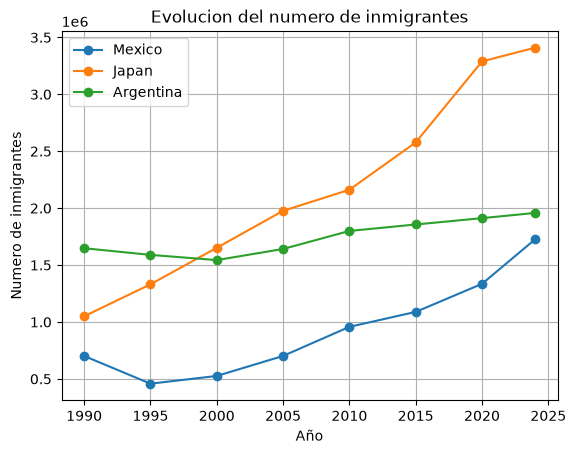

In [108]:
# Pregunta 8
mexico = df[df["entity"] == "Mexico"]
japan = df[df["entity"] == "Japan"]
argentina = df[df["entity"] == "Argentina"]

plt.plot(mexico["year"], mexico["valor"], marker="o", label="Mexico")
plt.plot(japan["year"], japan["valor"], marker="o", label="Japan")
plt.plot(argentina["year"], argentina["valor"], marker="o", label="Argentina")

plt.title("Evolucion del numero de inmigrantes")
plt.xlabel("Año")
plt.ylabel("Numero de inmigrantes")
plt.legend()
plt.grid(True)
plt.show()


**Interpretación:**

*(Se puede ver que el que mayor numero de inmigrantes tiene es japon, lo cual denota que ha crecido mas, a nivel economico que los otros dos)*

### Pregunta 9 — Visualización integradora

Crea dos gráficas de barras (horizontales o verticales) con el Top 10 de países según tu indicador en la primera consulta el año de tu nacimiento, y en la segunda el año 2023, ordenados de mayor a menor.  Qué movimientos hubo en ambas gráficas?
Agrega título y etiquetas de ejes.

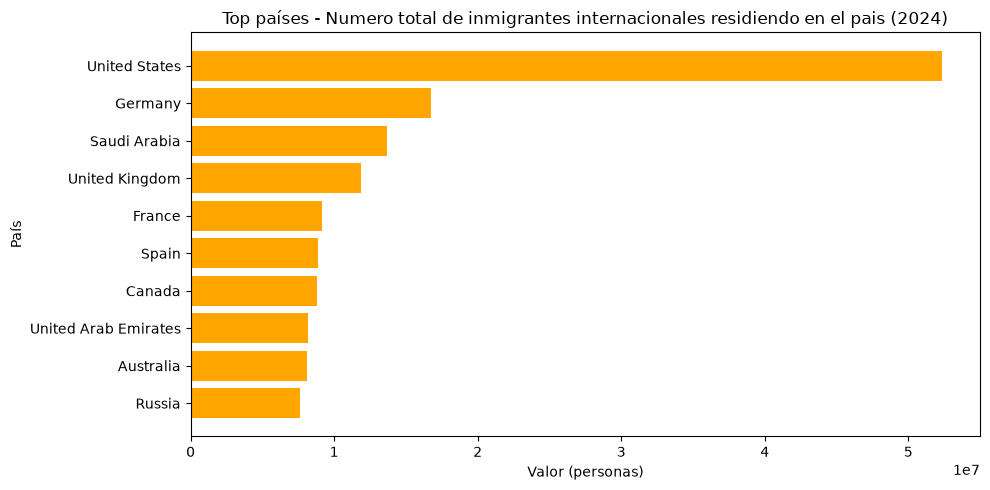

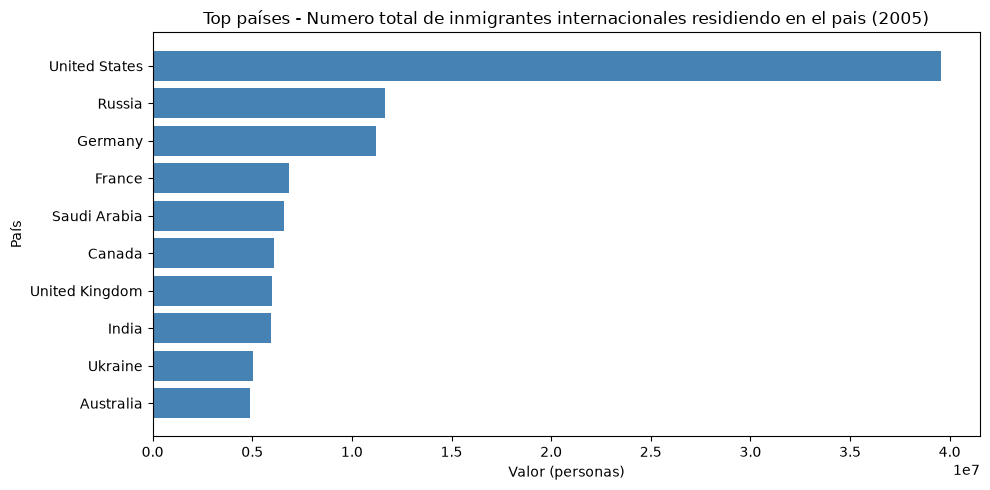

In [109]:
# Pregunta 9
# Tu codigo aqui
df_paises = df[df[config["filtro_paises"]].notnull()]

anio_consultado = 2024

top = (
    df_paises[df_paises['year'] == anio_consultado]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='orange')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()

anio_consultado2 = 2005

top = (
    df_paises[df_paises['year'] == anio_consultado2]
    .sort_values('valor', ascending=False)
    .head(10)
)
# Grafica de barras horizontales
plt.figure(figsize=(10, 5))
plt.barh(top['entity'], top['valor'], color='steelblue')

plt.xlabel(f"Valor ({config['unidad']})")
plt.ylabel("País")
plt.title(f"Top países - {config['descripcion']} ({anio_consultado2})")

plt.gca().invert_yaxis()  # para que el país con el valor mas alto quede arriba
plt.tight_layout()
plt.show()


**Interpretación:**

*(Desde los primeros años los paises mas desarrollados son los que tienen mayor numero de inmigrantes)*

## 5. Conclusión general

En 5 - 10 líneas, resume qué aprendiste sobre el dataset que te tocó trabajar: ¿qué
patrones encontraste?, ¿qué limitaciones tiene la información (por ejemplo, valores
absolutos sin normalizar por población, datos faltantes, etc.)?, ¿qué harías distinto si
tuvieras más tiempo?

*(Aprendi a poder extraer informacion mediante las librerias que tiene pandas, las cuales te facilitan la extraccion de datos y poder entender que los datos son la base de todo, ya que con ellos se toman decisiones las cuales afectan negativamente o positivamente a una empresa)*

## 6. Entrega

1. Verifica que el notebook corra completo de arriba hacia abajo sin errores (`Kernel > Restart & Run All`).
2. Guarda el archivo con el nombre: `apellido_nombre_examen_parcial1.ipynb`.
3. Súbelo al repositorio de GitHub del curso, en una carpeta para este examen.
4. Comparte el link de tu repo y envia una copia del notebook por teams.
